<a href="https://colab.research.google.com/github/amanpoonia/Derivatives/blob/main/BSCall%26put.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Black scholes

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy as sp
import scipy.stats as sps

In [2]:
# weiner process
def weiner(n):
  dt = (1/n)
  z = np.random.normal(0,1,n)
  dw = z*dt**0.5
  w = np.cumsum(dw)

  return w

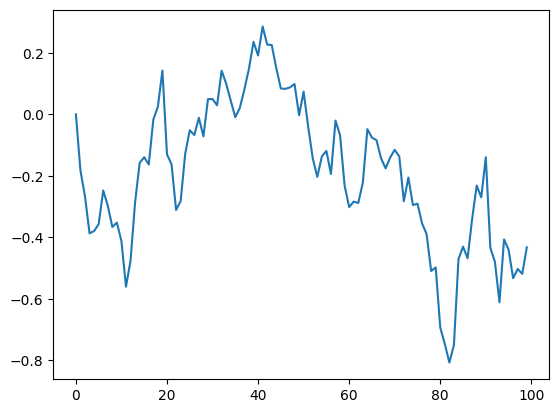

In [4]:
sim_weiner = weiner(100)
sim_weiner
plt.plot(sim_weiner)

**geometric brownian motion**

In [29]:
#geometric brownian motion

#the log prices of the stock follow a geometric brownian motion

def BS(mu, sigma, n):
  dt = (1/n)
  rt = np.random.normal((mu-sigma**2)*dt/2, sigma*dt**0.5, n)

  bs = np.cumsum(rt)
  st = np.exp(bs)
  return st


In [32]:
#prof gbm
def GBMSim(mu,sigma,n):
    #Take n to be the number of trading time intervals (say, minutes)
    #of the period (say, year)
    dt=1/n; #One time interval
    rt=np.random.normal((mu-sigma**2/2)*dt,(sigma*dt**0.5),n)
    W=np.cumsum(rt)
    St=np.exp(W)
    return St

In [31]:
#set seed
np.random.seed(11)

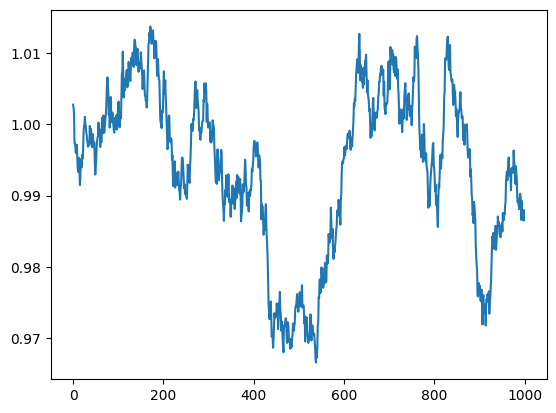

In [30]:
sim_gbm = BS(0.0002, 0.05, 1000)
sim_gbm
plt.plot(sim_gbm)

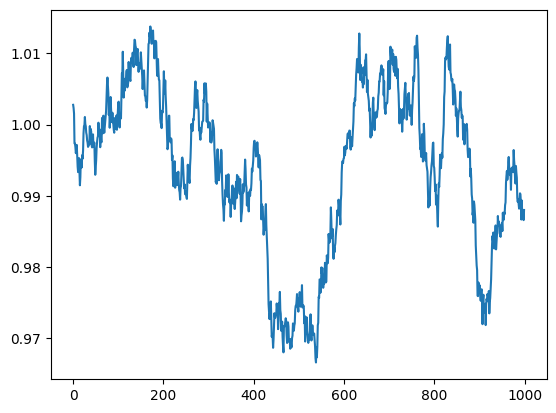

In [33]:
sim_gbm = GBMSim(0.0002, 0.05, 1000)
sim_gbm
plt.plot(sim_gbm)

In [6]:
#prof call put

'''
sigma = 0.3; #annual volatility
r = 0.05;    #annual continuously compounded risk-free interest rate
taumax = 7;  #maximum (time to) maturity
vecttau = np.insert(np.arange(taumax,0,-taumax/4),4,0);#(time to) maturity vector
nbtau = len(vecttau);        #(time to) maturity vector size
K = 100;     #exercise price
Smax = 2*K;  #maximum stock price
S = np.arange(0.2,Smax,Smax/999);# % stock p
tau=7
'''


def BScallPrice(sigma,K,tau,S,r):
    d1 = (np.log(S/K)+(r+(1/2)*sigma**2)*tau)/(sigma*np.sqrt(tau));
    d2 = d1-sigma*np.sqrt(tau);
    c = S*sps.norm.cdf(d1)-K*np.exp(-r*tau)*sps.norm.cdf(d2);
    return c

def BSputPrice(sigma,K,tau,S,r):
    d1 = (np.log(S/K)+(r+(1/2)*sigma**2)*tau)/(sigma*np.sqrt(tau));
    d2 = d1-sigma*np.sqrt(tau);
    c = S*sps.norm.cdf(d1)-K*np.exp(-r*tau)*sps.norm.cdf(d2);
    p = c+K*np.exp(-r*tau)-S;
    return p

#BScallPrice(sigma,K,tau,100,r)

#BSputPrice(sigma,K,tau,100,r)

sigma = 0.4; #annual volatility
r = 0.02;    #annual continuously compounded risk-free interest rate
tau = 5;
K=50
S=50

BScallPrice(sigma,K,tau,S,r)

np.float64(18.917476607987062)

In [8]:
sigma = 0.3; #annual volatility
r = 0.05;    #annual continuously compounded risk-free interest rate
K = 100;     #exercise price
tau=7
S0=25;

BScallPrice(sigma,K,tau,S0,r)

np.float64(1.4194224754232718)

In [9]:
sigma = 0.3; #annual volatility
r = 0.05;    #annual continuously compounded risk-free interest rate
K = 100;     #exercise price
tau=7
S0=25;

BSputPrice(sigma,K,tau,S0,r)

np.float64(46.888231447294615)

In [10]:
sigma = 1.2
r = 0.05;    #annual continuously compounded risk-free interest rate
K = 100;     #exercise price
tau=7
S0=25;

BSputPrice(sigma,K,tau,S0,r)

np.float64(65.91726217006935)